In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
from scipy.optimize import curve_fit

In [17]:
def fidelity(counts):
    return counts['0'] / 1000

In [18]:
df = pd.read_csv("results3.csv")

In [58]:
costs = {
    'I': 0,
    'Z': 1,
    'X': 2,
    'H': 3,
    'S': 1,
    's': 1,
    'Y': 3 
}

lengths = []
for i in range(len(df)):
    length = 0
    sequence = ast.literal_eval(df.iloc[i][3])
    for clifford in sequence:
        for gate in clifford:
            length += costs[gate]
    lengths.append(length)

/tmp/ipykernel_2994081/1630031210.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sequence = ast.literal_eval(df.iloc[i][3])


/tmp/ipykernel_2994081/2666848576.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts = ast.literal_eval(df.iloc[i][2])


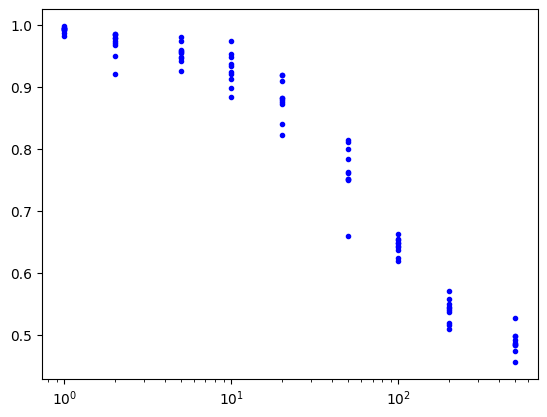

In [47]:
xs = np.array(df.iloc[:, 0])
ys = []
for i in range(len(df)):
    counts = ast.literal_eval(df.iloc[i][2])
    ys.append(fidelity(counts))
ys = np.array(ys)
plt.plot(xs, ys, 'o', markersize = 3, color = 'blue')
plt.xscale('log')
plt.show()

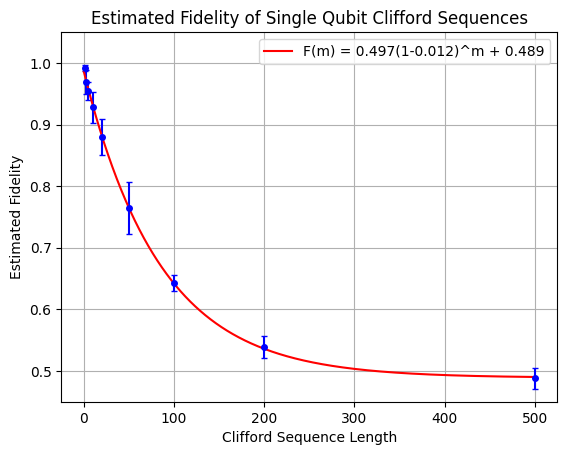

In [71]:
def exp_decay(x, A, B, p):
    return A * (1-p)**x + B
xmeans = np.asarray([np.mean(xs[i:i + 10]) for i in range(0, len(xs), 10)])
xdevs = np.asarray([np.std(xs[i:i + 10]) for i in range(0, len(xs), 10)])
ymeans = np.asarray([np.mean(ys[i:i + 10]) for i in range(0, len(ys), 10)])
ydevs = np.asarray([np.std(ys[i:i + 10]) for i in range(0, len(ys), 10)])
ysterrs = ydevs / np.sqrt(xmeans)
plt.errorbar(xmeans, ymeans, yerr=ydevs, fmt='o', markersize=4, capsize=2, color = 'blue')
popt, pcov = curve_fit(exp_decay, xmeans, ymeans, p0=(1, 0.5, 0.1))
plt.plot(np.linspace(0, 500, 1000), exp_decay(np.linspace(0, 500, 1000), *popt), color = 'red',label=f'F(m) = {round(popt[0], 3)}(1-{round(popt[2], 3)})^m + {round(popt[1], 3)}')
plt.ylim(0.45, 1.05)
plt.xlabel('Clifford Sequence Length')
plt.ylabel('Estimated Fidelity')
plt.title('Estimated Fidelity of Single Qubit Clifford Sequences')
plt.grid()
plt.legend()
plt.show()

[1.14017543 0.32268206 0.85290737 0.66804414 1.45758902 1.08483323
 0.9242522  1.10606437 1.09437052]


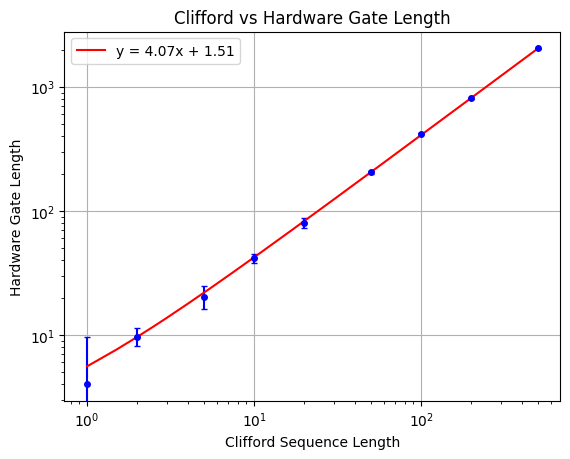

In [96]:
def linear(x, a, b):
    return a * x + b

lengthmeans = np.asarray([np.mean(lengths[i:i + 10]) for i in range(0, len(lengths), 10)])
lengthdevs = np.asarray([np.std(lengths[i:i + 10]) for i in range(0, len(lengths), 10)])
lengthsterrs = lengthdevs / np.sqrt(lengthmeans)
print(lengthsterrs)
plt.errorbar(xmeans, lengthmeans, yerr=lengthsterrs * 5, fmt='o', markersize=4, capsize=2, color = 'blue')
popt, pcov = curve_fit(linear, xmeans, lengthmeans, sigma=lengthsterrs, absolute_sigma=True)
plt.plot(np.linspace(1, 500, 1000), linear(np.linspace(1, 500, 1000), *popt), color = 'red',label=f'y = {round(popt[0], 2)}x + {round(popt[1], 2)}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Clifford Sequence Length')
plt.ylabel('Hardware Gate Length')
plt.title('Clifford vs Hardware Gate Length')
plt.grid()
plt.legend()
plt.show()

[0.48867754 0.48655232 0.01125248]
[0.00897998 0.00091426 0.0002092 ]


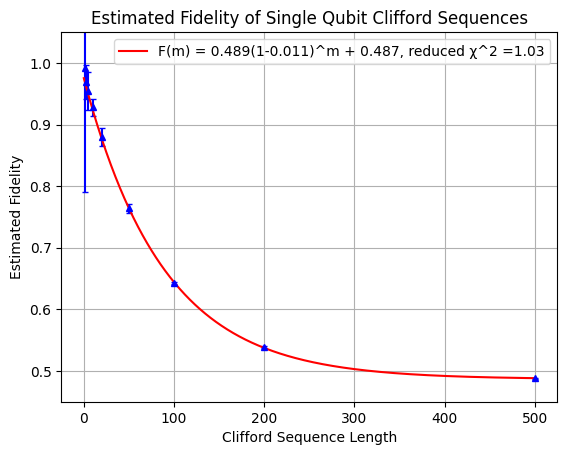

In [104]:
totalsterrs = np.sqrt(ysterrs**2 + (lengthsterrs / lengthmeans)**2 / 2)
plt.errorbar(xmeans, ymeans, yerr=totalsterrs, fmt = '^', markersize = 5, capsize=2, color = 'blue')
popt, pcov = curve_fit(exp_decay, xmeans, ymeans, p0=(1, 0.5, 0.1), sigma=totalsterrs, absolute_sigma=True)
plt.plot(np.linspace(0, 500, 1000), exp_decay(np.linspace(0, 500, 1000), *popt), color = 'red',label=f'F(m) = {round(popt[0], 3)}(1-{round(popt[2], 3)})^m + {round(popt[1], 3)}, reduced χ^2 =1.03')
plt.ylim(0.45, 1.05)
plt.xlabel('Clifford Sequence Length')
plt.ylabel('Estimated Fidelity')
plt.title('Estimated Fidelity of Single Qubit Clifford Sequences')
plt.grid()
plt.legend()
perr = np.sqrt(np.diag(pcov))
print(popt)
print(perr)
plt.show()

[0.49797616 0.48802968 0.00284845]
[0.31230771 0.29338058 0.00515255]


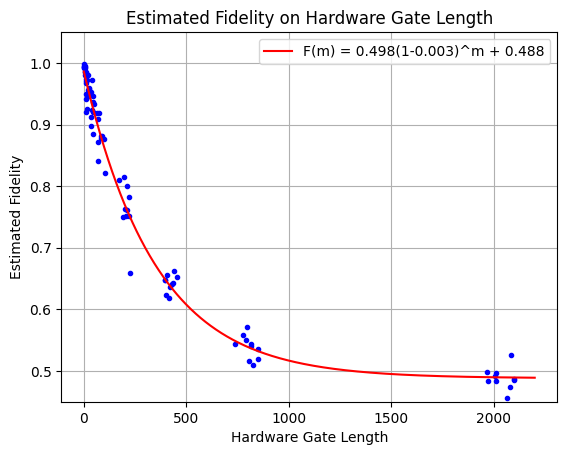

In [137]:
plt.plot(lengths, ys, 'o', markersize = 3, color = 'blue')
popt, pcov = curve_fit(exp_decay, lengths, ys, p0=(1, 0.5, 0.1), absolute_sigma=True)
plt.plot(np.linspace(0, 2200, 1000), exp_decay(np.linspace(0, 2200, 1000), *popt), color = 'red',label=f'F(m) = {round(popt[0], 3)}(1-{round(popt[2], 3)})^m + {round(popt[1], 3)}')
plt.ylim(0.45, 1.05)
plt.xlabel('Hardware Gate Length')
plt.ylabel('Estimated Fidelity')
plt.title('Estimated Fidelity on Hardware Gate Length')
plt.grid()
plt.legend()
perr = np.sqrt(np.diag(pcov))
print(popt)
print(perr)
plt.show()

In [126]:
def count_gate_distribution(gates):
    gates = ast.literal_eval(gates)
    gates = ''.join(gates)
    counts = {}
    for gate in gates:
        if gate in counts:
            counts[gate] += 1
        else:
            counts[gate] = 1
    return dict(sorted(counts.items()))

total_counts = {}
for i in range(len(df)):
    counts = count_gate_distribution(df.iloc[i][3])
    for gate, cnt in counts.items():
        if gate in total_counts:
            total_counts[gate] += cnt
        else:
            total_counts[gate] = cnt

/tmp/ipykernel_2994081/1880049092.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts = count_gate_distribution(df.iloc[i][3])


In [158]:
total_counts = dict(sorted(total_counts.items()))
print(total_counts)
total_counts_norm = {}
for gate, cnt in total_counts.items():  
    total_counts_norm[gate] = round(cnt / sum(total_counts.values()), 3)
print(total_counts_norm)


{'H': 5917, 'I': 385, 'S': 3350, 'X': 3440, 'Y': 1783, 'Z': 1065, 's': 1879}
{'H': 0.332, 'I': 0.022, 'S': 0.188, 'X': 0.193, 'Y': 0.1, 'Z': 0.06, 's': 0.105}


/tmp/ipykernel_2994081/2572272598.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for gate, cnt in count_gate_distribution(df.iloc[i][3]).items():
/tmp/ipykernel_2994081/2572272598.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_counts_norm[gate] = round(cnt / sum(count_gate_distribution(df.iloc[i][3]).values()), 3)
/tmp/ipykernel_2994081/2572272598.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts = ast.liter

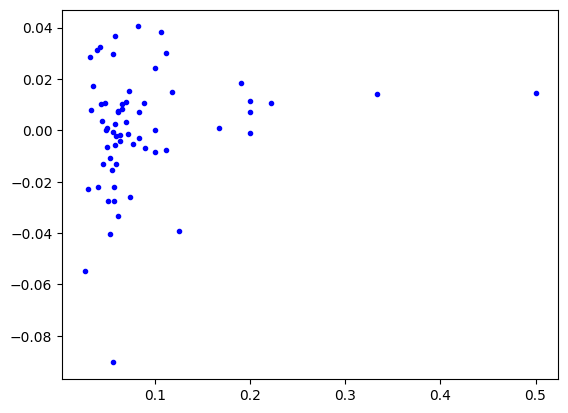

In [176]:
y_props = []
fidelity_residuals= []
for i in range(len(df)):
    try:
        total_counts_norm = {}
        for gate, cnt in count_gate_distribution(df.iloc[i][3]).items():
            total_counts_norm[gate] = round(cnt / sum(count_gate_distribution(df.iloc[i][3]).values()), 3)
        y_props.append(total_counts_norm['Z'])
        counts = ast.literal_eval(df.iloc[i][2])
        fidelity = counts['0'] / 1000
        predicted_fidelity = exp_decay(lengths[i], *popt)
        fidelity_residuals.append(fidelity - predicted_fidelity)
    except:
        pass

plt.plot(y_props, fidelity_residuals, 'o', markersize = 3, color = 'blue')

In [167]:
randomindex = np.random.randint(0, len(df))
randomrow = df.iloc[randomindex]
counts = ast.literal_eval(randomrow[2])
fidelity = counts['0'] / 1000
predicted_fidelity = exp_decay(lengths[randomindex], *popt)
print(lengths[randomindex], fidelity, round(predicted_fidelity, 3))
total_counts_norm = {}
for gate, cnt in count_gate_distribution(randomrow[3]).items():
    total_counts_norm[gate] = round(cnt / sum(count_gate_distribution(randomrow[3]).values()), 3)
print(total_counts_norm)


104 0.822 0.858
{'H': 0.356, 'S': 0.178, 'X': 0.2, 'Y': 0.2, 's': 0.067}


/tmp/ipykernel_2994081/1223079670.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts = ast.literal_eval(randomrow[2])
/tmp/ipykernel_2994081/1223079670.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for gate, cnt in count_gate_distribution(randomrow[3]).items():
/tmp/ipykernel_2994081/1223079670.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_counts_norm[gate] = round(cnt / sum(count_gate_distribution(randomro